# **step 1:**

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# **WB desciptive analysis**

In [2]:
# Load Warner Bros Discovery dataset
wbd = pd.read_csv("D:\Winter 25-26\CRM\Review_Code\WBD")

# Display first rows
print("Dataset Preview:")
print(wbd.head())

# Dataset info
print("\nDataset Info:")
print(wbd.info())

# Shape
print("\nDataset Shape:", wbd.shape)

Dataset Preview:
         Date      Close       High        Low       Open   Volume       Fark  \
0  2012-02-06  22.805313  22.933062  22.636688  22.677568  1730575  22.820644   
1  2012-02-07  23.142565  23.208994  22.662237  22.723557  2799880  22.805313   
2  2012-02-08  23.173223  23.387838  22.989269  23.096577  2131760  23.142565   
3  2012-02-09  23.004599  23.219213  22.927952  23.208994  2404762  23.173223   
4  2012-02-10  22.887072  22.968830  22.759325  22.851303  2142328  23.004599   

     Getiri       MA_5  Volatility   Volume_Ratio  Daily_Change      MA_20  \
0 -0.000672  22.414921    0.296373   75884.728775      0.127745  22.283342   
1  0.014788  22.661216    0.546757  120983.997556      0.419008  22.378641   
2  0.001325  22.854369    0.398569   91992.380793      0.076647  22.455289   
3 -0.007277  22.989269    0.291262  104533.969055     -0.204395  22.507665   
4 -0.005109  23.002554    0.209505   93604.286147      0.035769  22.539857   

  Day_of_Week     EMA_10  


<>:2: SyntaxWarning: invalid escape sequence '\W'
<>:2: SyntaxWarning: invalid escape sequence '\W'
C:\Users\vasun\AppData\Local\Temp\ipykernel_16868\3616934983.py:2: SyntaxWarning: invalid escape sequence '\W'
  wbd = pd.read_csv("D:\Winter 25-26\CRM\Review_Code\WBD")


In [3]:
# Convert date column to datetime
wbd["Date"] = pd.to_datetime(wbd["Date"])

# Sort by date
wbd = wbd.sort_values("Date")

In [4]:
print("\nDescriptive Statistics:")
print(wbd.describe())


Descriptive Statistics:
                                Date        Close         High          Low  \
count                           3487  3487.000000  3487.000000  3487.000000   
mean   2019-01-09 19:03:54.356180224    25.426525    25.816492    25.026339   
min              2012-02-06 00:00:00     6.710000     6.980000     6.640000   
25%              2015-07-25 12:00:00    18.545000    19.100000    18.000000   
50%              2019-01-10 00:00:00    26.549999    26.908533    26.160000   
75%              2022-06-27 12:00:00    30.969999    31.458865    30.583817   
max              2025-12-16 00:00:00    77.269997    78.139999    74.510002   
std                              NaN    10.325862    10.442268    10.195860   

              Open        Volume         Fark       Getiri         MA_5  \
count  3487.000000  3.487000e+03  3487.000000  3487.000000  3487.000000   
mean     25.424585  1.168950e+07    25.424781     0.000430    25.422534   
min       6.670000  6.474000e+05     6

In [5]:
print("\nMissing Values:")
print(wbd.isnull().sum())


Missing Values:
Date            0
Close           0
High            0
Low             0
Open            0
Volume          0
Fark            0
Getiri          0
MA_5            0
Volatility      0
Volume_Ratio    0
Daily_Change    0
MA_20           0
Day_of_Week     0
EMA_10          0
dtype: int64


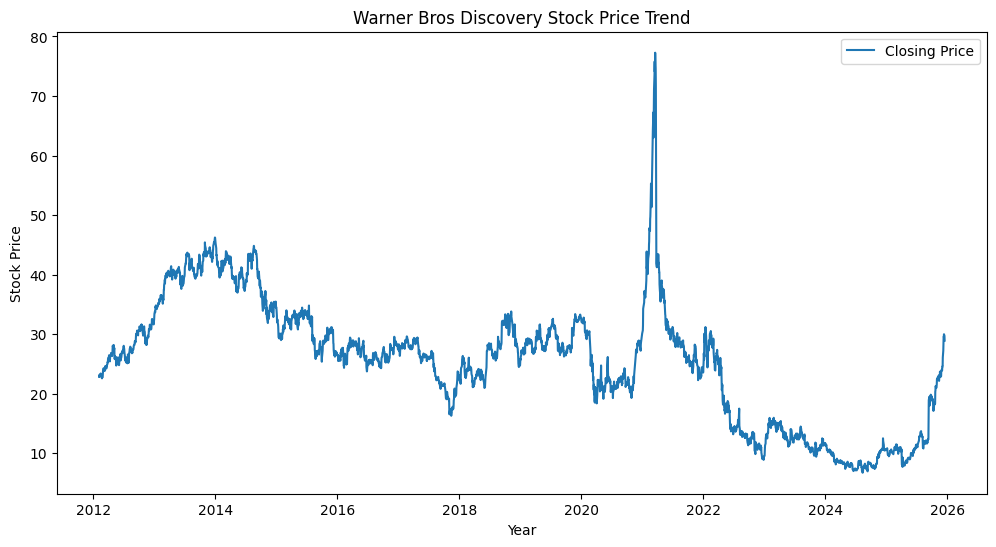

In [6]:
plt.figure(figsize=(12,6))

plt.plot(wbd["Date"], wbd["Close"], label="Closing Price")

plt.title("Warner Bros Discovery Stock Price Trend")
plt.xlabel("Year")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

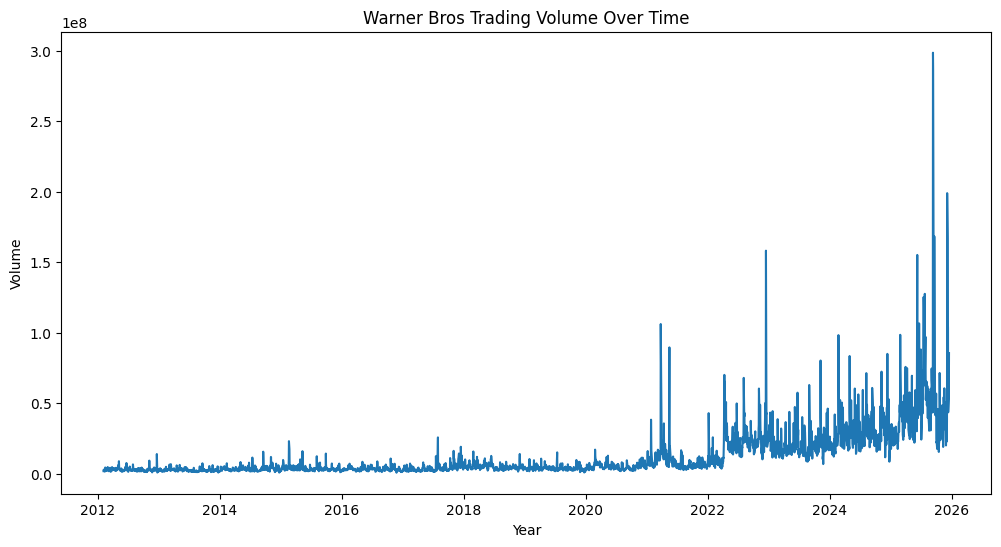

In [7]:
#Trading Volume Analysis
plt.figure(figsize=(12,6))

plt.plot(wbd["Date"], wbd["Volume"])

plt.title("Warner Bros Trading Volume Over Time")
plt.xlabel("Year")
plt.ylabel("Volume")

plt.show()

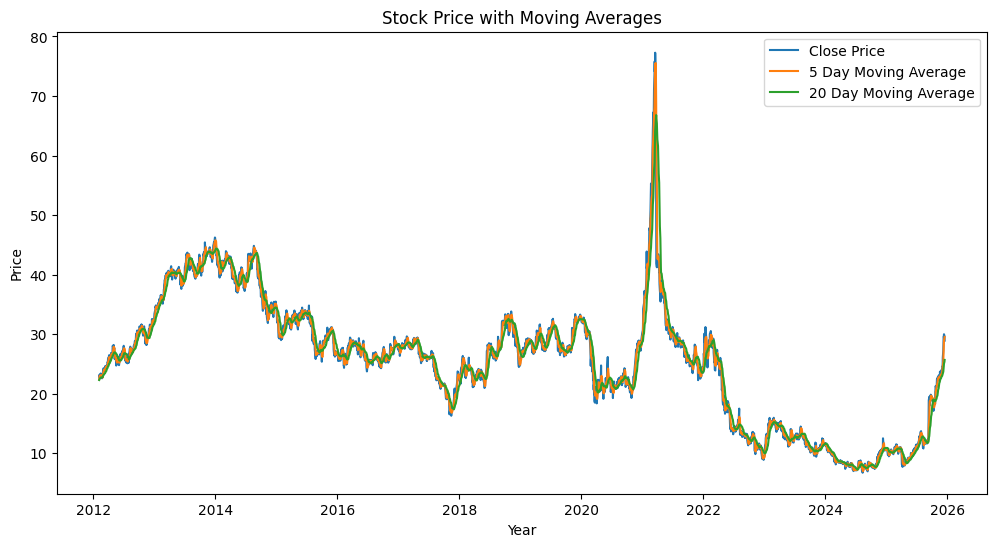

In [10]:
# Moving Averages
plt.figure(figsize=(12,6))

plt.plot(wbd["Date"], wbd["Close"], label="Close Price")
plt.plot(wbd["Date"], wbd["MA_5"], label="5 Day Moving Average")
plt.plot(wbd["Date"], wbd["MA_20"], label="20 Day Moving Average")

plt.title("Stock Price with Moving Averages")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()

plt.show()

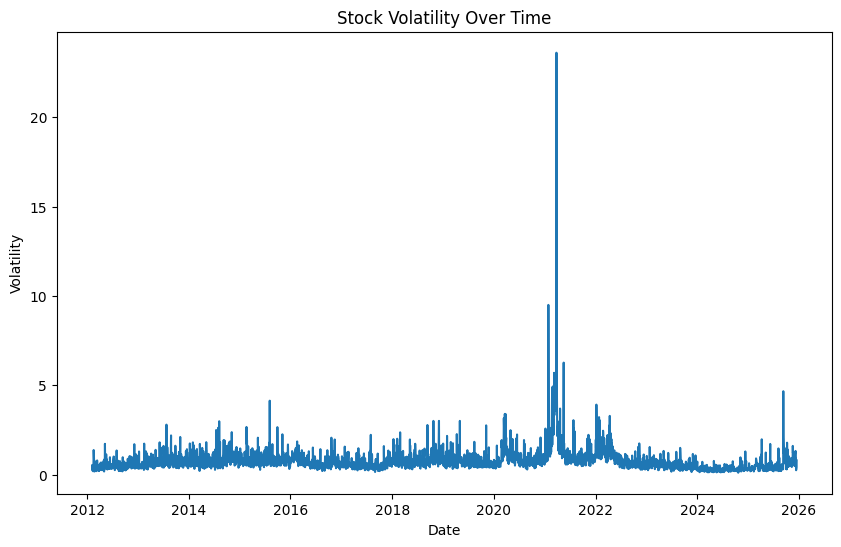

In [56]:
#  Volatility Analysis

plt.figure(figsize=(10,6))
plt.plot(wbd["Date"], wbd["Volatility"])
plt.title("Stock Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

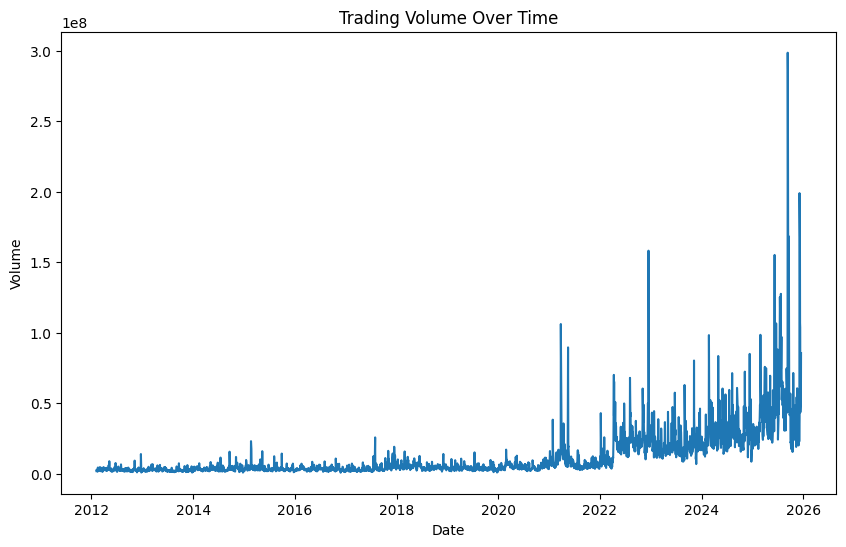

In [57]:

#  Trading Volume Trend
plt.figure(figsize=(10,6))
plt.plot(wbd["Date"], wbd["Volume"])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()


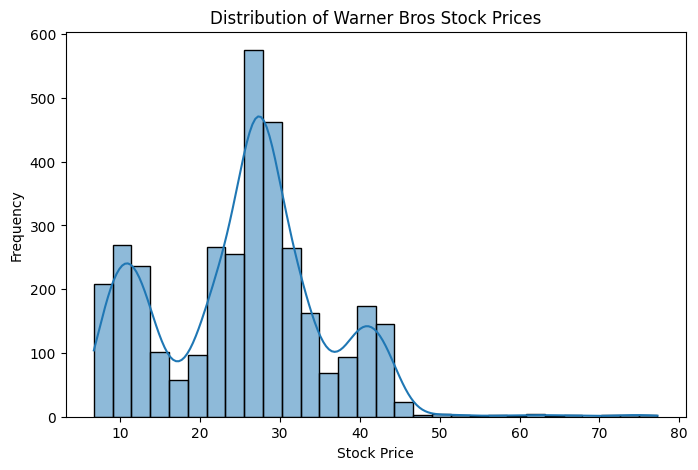

In [12]:
# Price Distribution
plt.figure(figsize=(8,5))
import seaborn as sns
sns.histplot(wbd["Close"], bins=30, kde=True)

plt.title("Distribution of Warner Bros Stock Prices")
plt.xlabel("Stock Price")
plt.ylabel("Frequency")

plt.show()

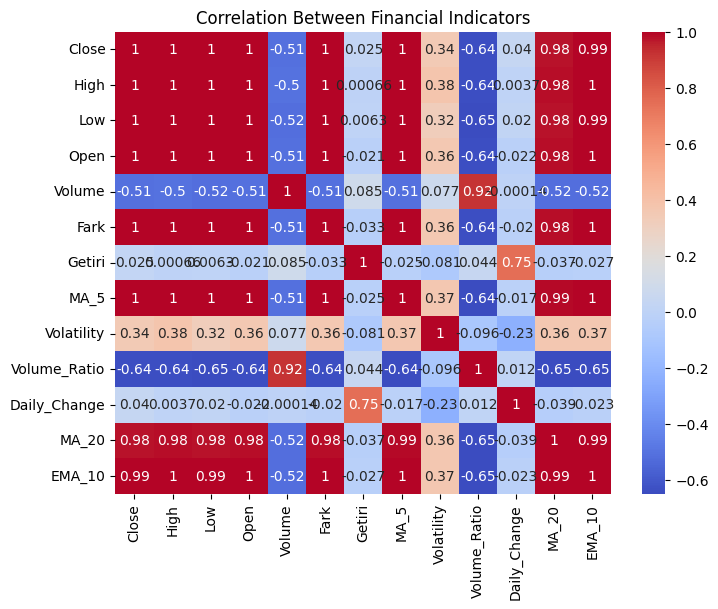

In [13]:
# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(wbd.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Between Financial Indicators")

plt.show()

In [58]:
#  Summary Statistics
print("\nStock Summary Statistics:")
print(wbd[["Close", "Volatility", "Volume"]].describe())


Stock Summary Statistics:
             Close   Volatility        Volume
count  3487.000000  3487.000000  3.487000e+03
mean     25.426525     0.790153  1.168950e+07
std      10.325862     0.703722  1.737844e+07
min       6.710000     0.110000  6.474000e+05
25%      18.545000     0.459999  2.827528e+06
50%      26.549999     0.650001  4.515300e+06
75%      30.969999     0.939999  1.543655e+07
max      77.269997    23.610001  2.984433e+08



# **WARNER BROS FRANCHISE ANALYSIS**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
movies = pd.read_csv("tmdb_5000_movies.csv")

print("Dataset Shape:", movies.shape)

print("\nFirst 5 Rows:")
print(movies.head())

print("\nDataset Info:")
print(movies.info())

Dataset Shape: (4803, 20)

First 5 Rows:
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na... 

In [48]:
# Select Important Columns
# The dataset has many columns. Keep only relevant ones.

movies = movies[['title','release_date','revenue','budget','popularity','vote_average','production_companies']]

In [ ]:
# Filter Warner Bros Movies
# Warner Bros appears inside production_companies.

wb_movies = movies[movies['production_companies'].str.contains("Warner", na=False)]

print("Total Warner Bros Movies:", wb_movies.shape)
# Now you have only Warner Bros movies.

Total Warner Bros Movies: (343, 7)


In [50]:
# Remove Movies with Missing Revenue
wb_movies = wb_movies[wb_movies['revenue'] > 0]

In [51]:
# Top Warner Bros Movies by Revenue
top_movies = wb_movies.sort_values(by='revenue', ascending=False).head(10)

print(top_movies[['title','revenue']])

                                         title     revenue
3                        The Dark Knight Rises  1084939099
98           The Hobbit: An Unexpected Journey  1021103568
65                             The Dark Knight  1004558444
197   Harry Potter and the Philosopher's Stone   976475550
22         The Hobbit: The Desolation of Smaug   958400000
19   The Hobbit: The Battle of the Five Armies   956019788
113  Harry Potter and the Order of the Phoenix   938212738
8       Harry Potter and the Half-Blood Prince   933959197
114        Harry Potter and the Goblet of Fire   895921036
276    Harry Potter and the Chamber of Secrets   876688482


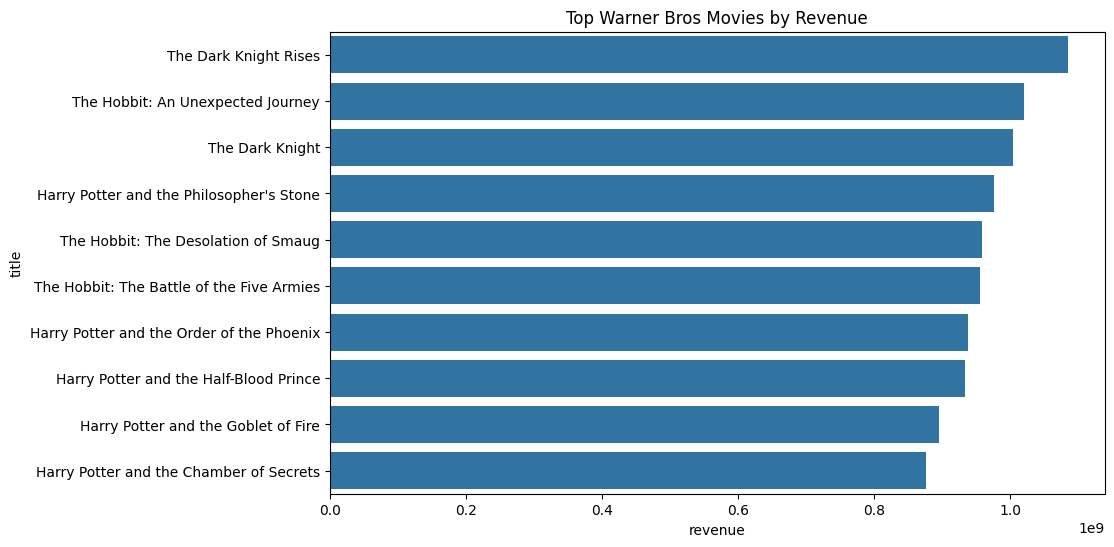

In [ ]:
# G1 — Top Warner Bros Movies
plt.figure(figsize=(10,6))

sns.barplot(x='revenue', y='title', data=top_movies)

plt.title("Top Warner Bros Movies by Revenue")

plt.show()
#This shows franchise success.

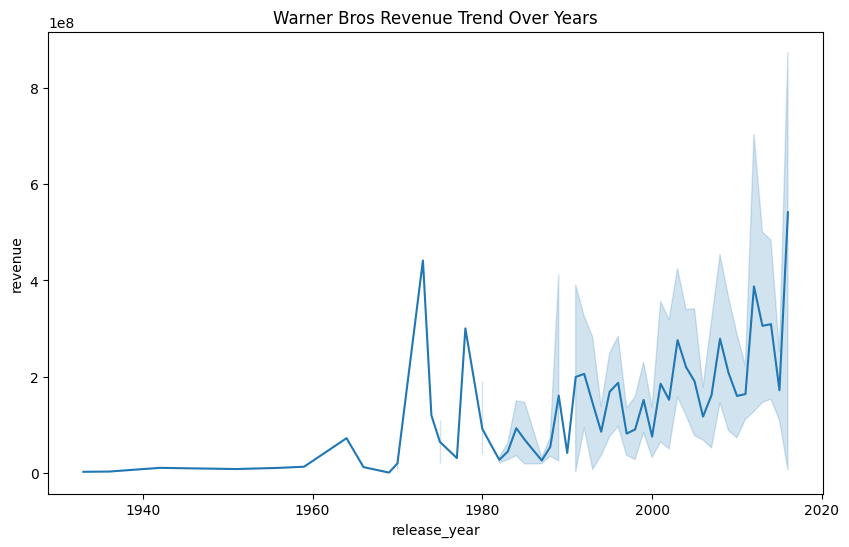

In [53]:
# G2 — Revenue Trend Over Time
# First extract year.

wb_movies['release_year'] = pd.to_datetime(wb_movies['release_date'], errors='coerce').dt.year
# Now visualize revenue trend.

plt.figure(figsize=(10,6))

sns.lineplot(x='release_year', y='revenue', data=wb_movies)

plt.title("Warner Bros Revenue Trend Over Years")

plt.show()

# Shows growth of Warner Bros movie performance.

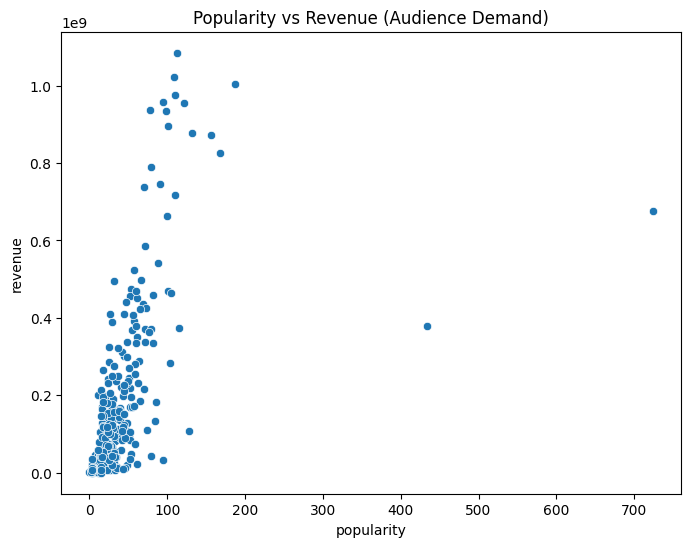

In [54]:
# G3— Popularity vs Revenue
plt.figure(figsize=(8,6))

sns.scatterplot(x='popularity', y='revenue', data=wb_movies)

plt.title("Popularity vs Revenue (Audience Demand)")

plt.show()

#This shows audience demand relationship.

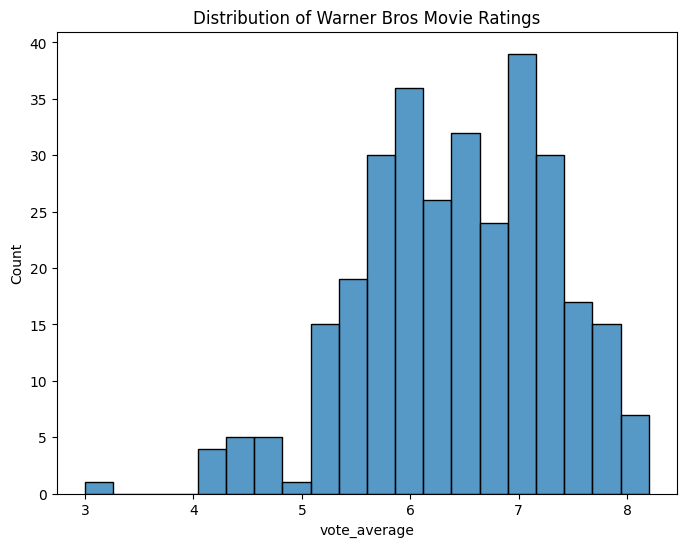

In [55]:
# G4 — Movie Rating Distribution
plt.figure(figsize=(8,6))

sns.histplot(wb_movies['vote_average'], bins=20)

plt.title("Distribution of Warner Bros Movie Ratings")

plt.show()

# **Netflix_churn**

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

STEP 2: Load Dataset

In [21]:
# Load dataset
netflix = pd.read_csv("Netflix_customer_churn.csv")

print("Dataset Shape:", netflix.shape)

print("\nFirst Rows:")
print(netflix.head())

print("\nDataset Info:")
print(netflix.info())

Dataset Shape: (5000, 14)

First Rows:
                            customer_id  age  gender subscription_type  \
0  a9b75100-82a8-427a-a208-72f24052884a   51   Other             Basic   
1  49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b   47   Other          Standard   
2  4d71f6ce-fca9-4ff7-8afa-197ac24de14b   27  Female          Standard   
3  d3c72c38-631b-4f9e-8a0e-de103cad1a7d   53   Other           Premium   
4  4e265c34-103a-4dbb-9553-76c9aa47e946   56   Other          Standard   

   watch_hours  last_login_days   region  device  monthly_fee  churned  \
0        14.73               29   Africa      TV         8.99        1   
1         0.70               19   Europe  Mobile        13.99        1   
2        16.32               10     Asia      TV        13.99        0   
3         4.51               12  Oceania      TV        17.99        1   
4         1.89               13   Africa  Mobile        13.99        1   

  payment_method  number_of_profiles  avg_watch_time_per_day favorite_g

In [22]:
# Check missing values
print("\nMissing Values:")
print(netflix.isnull().sum())

# Fill numeric columns with median
netflix = netflix.fillna(netflix.median(numeric_only=True))


Missing Values:
customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64


Encode Categorical Variables

Machine learning requires numeric features.

In [34]:
from sklearn.preprocessing import LabelEncoder

# Copy dataset
netflix_encoded = netflix.copy()

# Encode categorical columns
label_encoder = LabelEncoder()

for col in netflix_encoded.columns:
    if netflix_encoded[col].dtype == 'object':
        netflix_encoded[col] = label_encoder.fit_transform(netflix_encoded[col])

print("Categorical columns encoded successfully")

Categorical columns encoded successfully


In [26]:
netflix.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

In [35]:
# Target variable
y = netflix["churned"]

# Feature variables
X = netflix.drop("churned", axis=1)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (3500, 13)
Testing Data: (1500, 13)


In [39]:
# Logistic Regression Model
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("\nLOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, log_pred))

print(classification_report(y_test, log_pred))


LOGISTIC REGRESSION RESULTS
Accuracy: 0.888
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       753
           1       0.88      0.90      0.89       747

    accuracy                           0.89      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.89      0.89      0.89      1500



C:\Users\vasun\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [40]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))


RANDOM FOREST RESULTS
Accuracy: 0.9746666666666667
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       753
           1       0.98      0.97      0.97       747

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



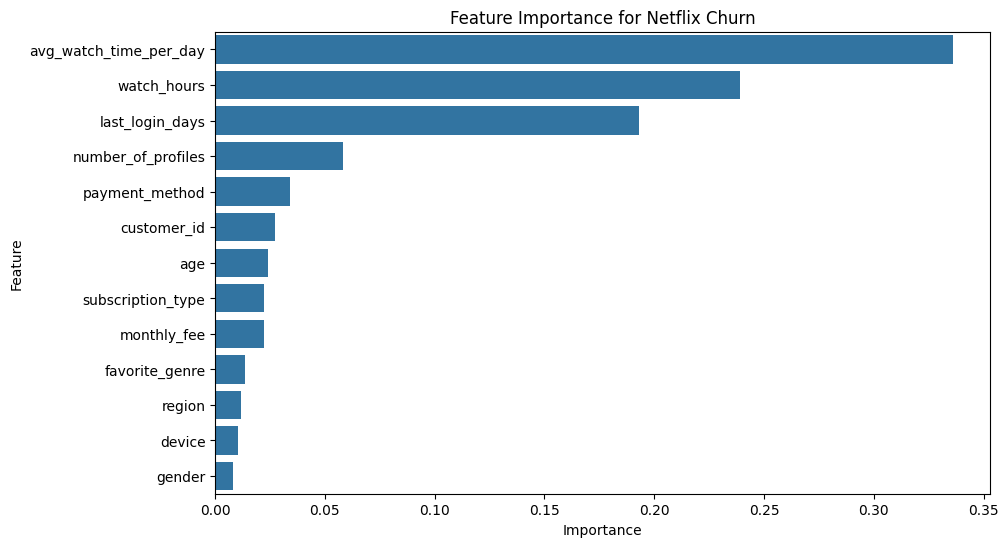

In [60]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
"Feature": X.columns,
"Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance for Netflix Churn")
plt.show()

In [41]:
# XGBoost Model
xgb_model = XGBClassifier(eval_metric="logloss")

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("\nXGBOOST RESULTS")
print("Accuracy:", accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))


XGBOOST RESULTS
Accuracy: 0.9946666666666667
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       753
           1       1.00      0.99      0.99       747

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



In [42]:
# Model Accuracy Comparison
results = pd.DataFrame({

"Model": ["Logistic Regression", "Random Forest", "XGBoost"],

"Accuracy": [

accuracy_score(y_test, log_pred),

accuracy_score(y_test, rf_pred),

accuracy_score(y_test, xgb_pred)

]
})
print("\nModel Comparison:")
print(results)


Model Comparison:
                 Model  Accuracy
0  Logistic Regression  0.888000
1        Random Forest  0.974667
2              XGBoost  0.994667


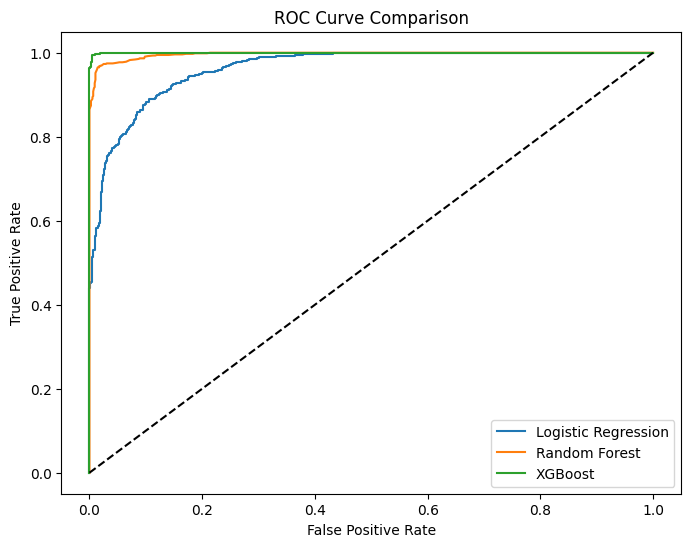

In [43]:
# ROC Curve (Important for Research Papers)
# Predict probabilities
log_prob = log_model.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

# Compute ROC values
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# Plot ROC curves
plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

# **SURVEY DATA ANALYSIS**


Brand Familiarity Distribution (%):
How familiar are you with Warner Bros as a brand?
Somewhat familiar                                                             30.508475
Very familiar                                                                 27.118644
Not familiar at all                                                           18.644068
Heard of it, but not sure what it offers                                      15.254237
Heard of it, but not sure what it offers, Not familiar at all                  3.389831
Very familiar, Somewhat familiar, Heard of it, but not sure what it offers     1.694915
Very familiar, Somewhat familiar                                               1.694915
Somewhat familiar, Not familiar at all                                         1.694915
Name: proportion, dtype: float64


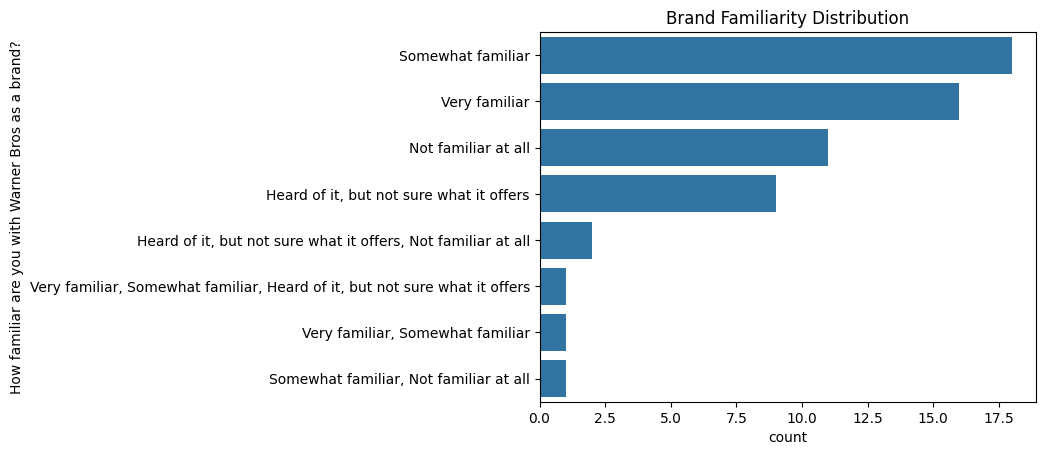


Popularity Comparison (%):
Compared to Netflix and Disney, how would you rate Warner Bros’ popularity?
Less popular       47.457627
Equally popular    27.118644
Not sure           23.728814
More popular        1.694915
Name: proportion, dtype: float64

Personalization Perception (%):
Do you feel streaming platforms personalize content well for you?
Somewhat          52.542373
Yes, very well    37.288136
Not at all         6.779661
Not really         3.389831
Name: proportion, dtype: float64

Which company builds stronger long-term relationship (%):
Which company builds a stronger long-term relationship with viewers?
Netflix                          51.724138
Disney                           27.586207
I don’t feel connected to any    17.241379
Warner Bros                       3.448276
Name: proportion, dtype: float64

Cross-tab: Familiarity vs Popularity (%)
Compared to Netflix and Disney, how would you rate Warner Bros’ popularity?  Equally popular  \
How familiar are you with Warner

In [ ]:
# CLEAN SURVEY ANALYSIS FOR YOUR STRUCTURE

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load survey
survey = pd.read_csv("Survey.csv")

survey.columns = survey.columns.str.strip()

#  BRAND FAMILIARITY

print("\nBrand Familiarity Distribution (%):")
familiarity_pct = survey[
    "How familiar are you with Warner Bros as a brand?"
].value_counts(normalize=True) * 100

print(familiarity_pct)

sns.countplot(
    y=survey["How familiar are you with Warner Bros as a brand?"],
    order=survey["How familiar are you with Warner Bros as a brand?"].value_counts().index
)
plt.title("Brand Familiarity Distribution")
plt.show()


#  POPULARITY COMPARISON
print("\nPopularity Comparison (%):")
popularity_pct = survey[
    "Compared to Netflix and Disney, how would you rate Warner Bros’ popularity?"
].value_counts(normalize=True) * 100

print(popularity_pct)


#  PERSONALIZATION PERCEPTION
print("\nPersonalization Perception (%):")
personalization_pct = survey[
    "Do you feel streaming platforms personalize content well for you?"
].value_counts(normalize=True) * 100

print(personalization_pct)


#  RELATIONSHIP BUILDING PERCEPTION
print("\nWhich company builds stronger long-term relationship (%):")
relationship_pct = survey[
    "Which company builds a stronger long-term relationship with viewers?"
].value_counts(normalize=True) * 100

print(relationship_pct)


#  CROSS-TAB: Familiarity vs Popularity
print("\nCross-tab: Familiarity vs Popularity (%)")

cross_tab = pd.crosstab(
    survey["How familiar are you with Warner Bros as a brand?"],
    survey["Compared to Netflix and Disney, how would you rate Warner Bros’ popularity?"],
    normalize='index'
) * 100

print(cross_tab)


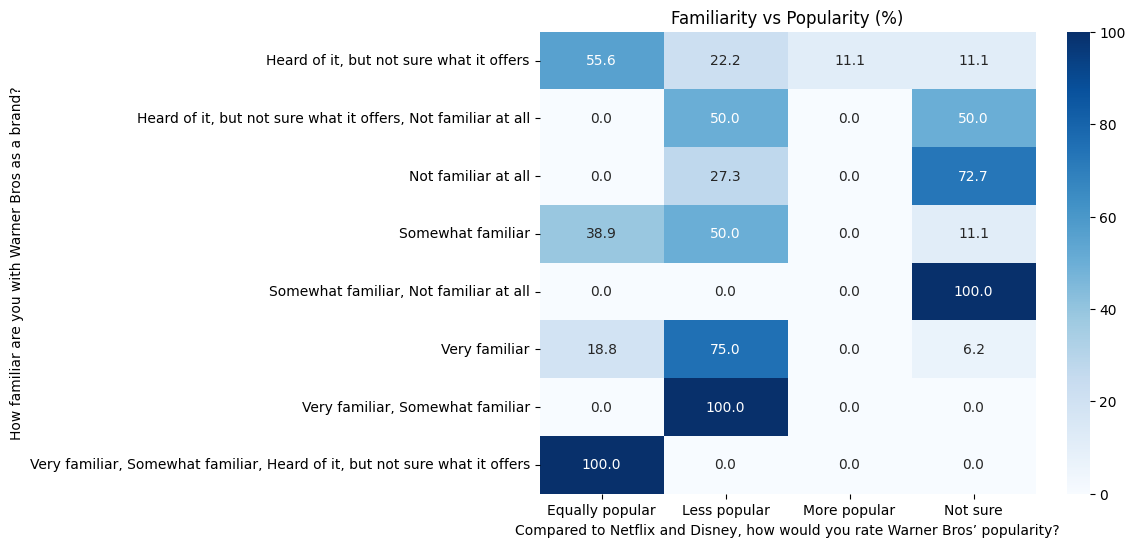

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(cross_tab, annot=True, fmt=".1f", cmap="Blues")
plt.title("Familiarity vs Popularity (%)")
plt.show()

In [59]:
crm_gap = pd.DataFrame({

"CRM Feature":[
"Personalization",
"Churn Prediction",
"Customer Data Integration",
"Recommendation Systems"
],

"Netflix":[
"AI Recommendation Engine",
"Predictive Churn Models",
"Unified Customer Data",
"Advanced ML Models"
],

"Warner Bros":[
"Limited Personalization",
"No Advanced Churn Prediction",
"Fragmented Customer Data",
"Basic Recommendation"
]

})

print(crm_gap)

                 CRM Feature                   Netflix  \
0            Personalization  AI Recommendation Engine   
1           Churn Prediction   Predictive Churn Models   
2  Customer Data Integration     Unified Customer Data   
3     Recommendation Systems        Advanced ML Models   

                    Warner Bros  
0       Limited Personalization  
1  No Advanced Churn Prediction  
2      Fragmented Customer Data  
3          Basic Recommendation  
